# CardioAI — Model Training

**Milestone 3: Model Training, Evaluation & Selection**

Trains and compares four classifiers per the project blueprint:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Each is evaluated with 5-fold cross-validation on the training set (Accuracy, Precision, Recall, F1, ROC-AUC), then the winning model is evaluated once on the held-out test set and persisted with `joblib` for use by `app.py`.

Explainability (SHAP) is included at the end, per the tech stack's "Explainable AI" requirement.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42


## Load Preprocessed Data

Reuses the exact train/test split and scaling produced in `02_Preprocessing.ipynb` — no re-splitting, no re-scaling, so there is zero risk of train/test leakage between notebooks.

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (479, 27), Test: (120, 27)


## Cross-Validated Model Comparison

5-fold stratified cross-validation on the training set only. Each model is scored on Accuracy, Precision, Recall, F1, and ROC-AUC.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False),
}

cv_results = {}

for name, model in candidate_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {metric: scores[f"test_{metric}"] for metric in scoring}
    print(f"{name}: mean ROC-AUC = {scores['test_roc_auc'].mean():.4f}")


Logistic Regression: mean ROC-AUC = 0.8637
Decision Tree: mean ROC-AUC = 0.7076


Random Forest: mean ROC-AUC = 0.8775


XGBoost: mean ROC-AUC = 0.8521


In [4]:
summary_rows = []
for name, metrics in cv_results.items():
    row = {"Model": name}
    for metric, values in metrics.items():
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display_cols = ["Model", "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]
summary_df_display = summary_df[display_cols].sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
summary_df_display.columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
summary_df_display


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.795439,0.805248,0.792687,0.794677,0.877493
1,Logistic Regression,0.807939,0.810310,0.817432,0.810931,0.863711
2,XGBoost,0.776623,0.790341,0.771939,0.776074,0.852069
3,Decision Tree,0.707763,0.713027,0.713605,0.709629,0.707556


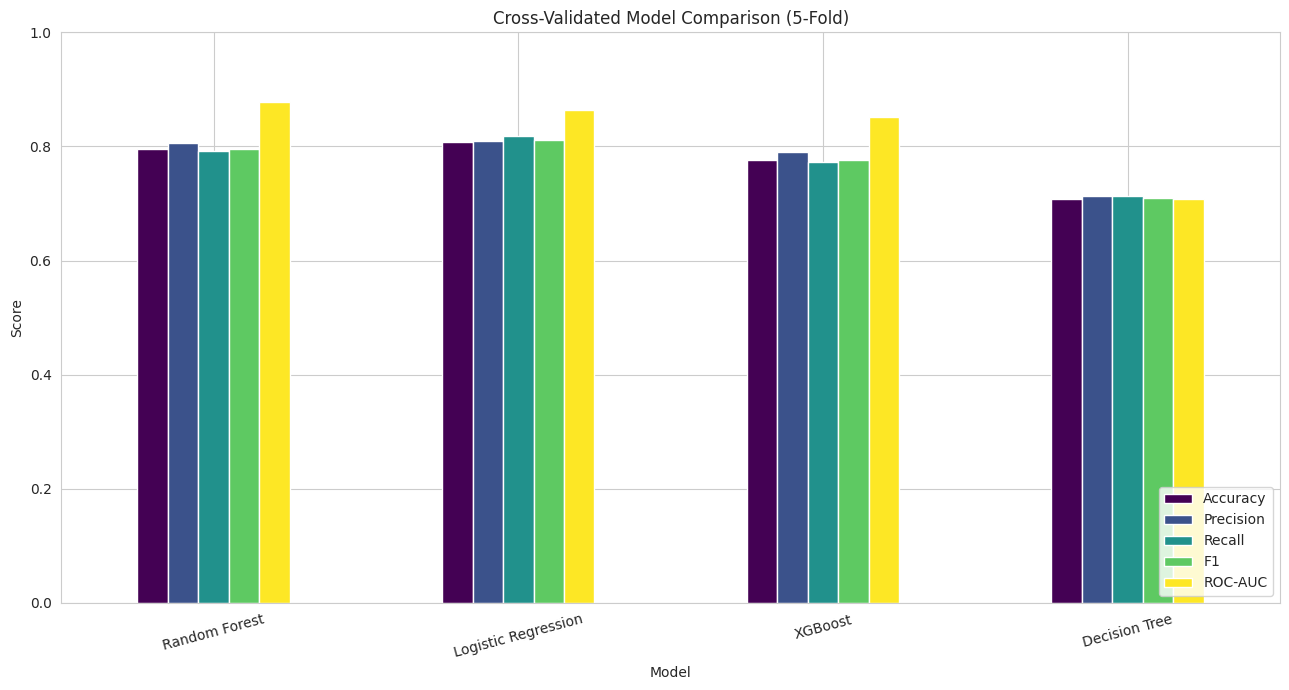

In [5]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
plot_df = summary_df_display.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(13, 7), colormap="viridis")
ax.set_ylabel("Score")
ax.set_title("Cross-Validated Model Comparison (5-Fold)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Hyperparameter Tuning for the Leading Candidate

Cross-validated ROC-AUC determines the leading model; we then run a light `GridSearchCV` on it to squeeze out additional performance before final test evaluation.

In [6]:
best_model_name = summary_df_display.iloc[0]["Model"]
print(f"Leading candidate by mean CV ROC-AUC: {best_model_name}")


Leading candidate by mean CV ROC-AUC: Random Forest


In [7]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1.0, 10.0],
        "solver": ["liblinear", "lbfgs"],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
    },
}

base_model = candidate_models[best_model_name]
grid = GridSearchCV(
    base_model, param_grids[best_model_name],
    cv=cv, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best params for {best_model_name}: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")


Best params for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV ROC-AUC: 0.8851


## Final Evaluation on the Held-Out Test Set

The tuned model is evaluated **once** on the test set — the same split produced in `02_Preprocessing.ipynb` and untouched until now.

In [8]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
}

print(f"Final Model: {best_model_name} (tuned)\n")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


Final Model: Random Forest (tuned)

Accuracy: 0.7667
Precision: 0.7667
Recall: 0.7667
F1: 0.7667
ROC-AUC: 0.8597

Full classification report:
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        60
     Disease       0.77      0.77      0.77        60

    accuracy                           0.77       120
   macro avg       0.77      0.77      0.77       120
weighted avg       0.77      0.77      0.77       120



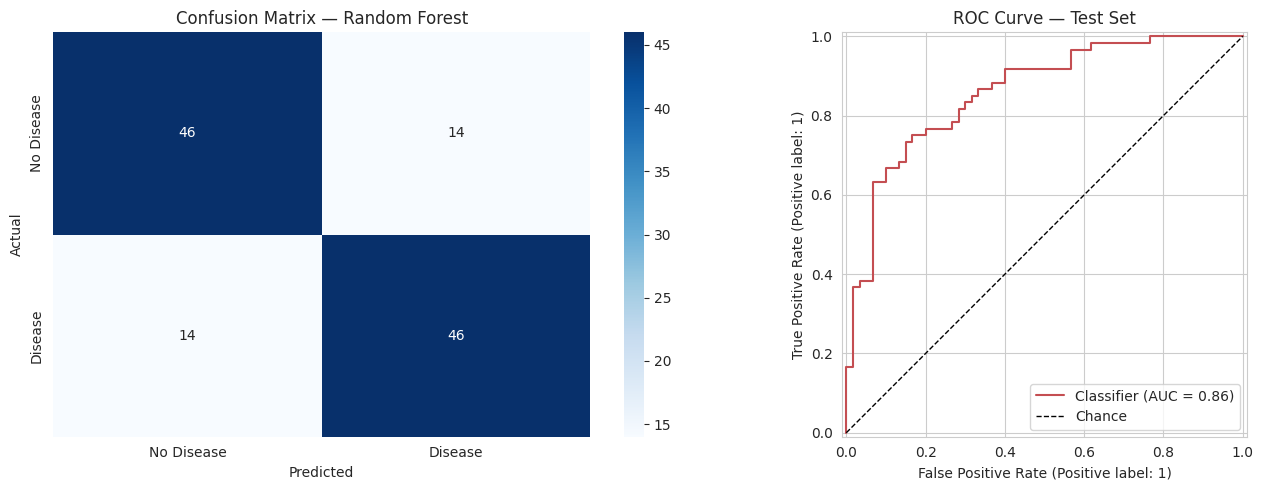

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color="#C44E52")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
axes[1].set_title("ROC Curve — Test Set")
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/final_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()


## Explainability — SHAP

Per the project's "Explainable AI" requirement, SHAP values show which features push each prediction toward "disease" vs "no disease" — this is what powers the AI assistant's explanation feature (FR-004) in the deployed app.

<Figure size 1000x600 with 0 Axes>

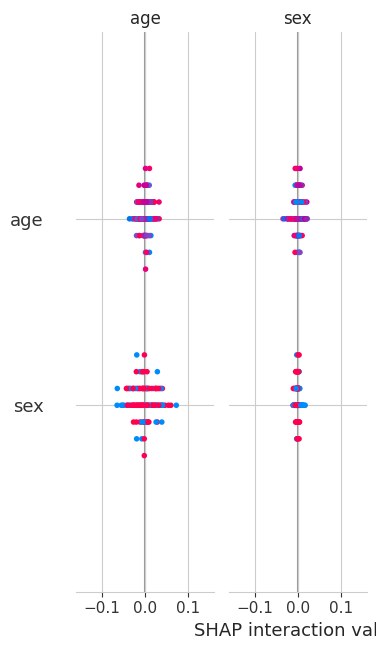

In [10]:
import shap

if best_model_name in ("XGBoost", "Random Forest", "Decision Tree"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test, check_additivity=False)
else:
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../images/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()


## Persist the Final Model

Saved for direct use by `app.py`'s `/predict` endpoint. The scaler and feature column order (saved in Notebook 02) must be applied identically at inference time.

In [11]:
joblib.dump(best_model, "../models/cardioai_model.pkl")

metadata = {
    "model_name": best_model_name,
    "best_params": grid.best_params_,
    "test_metrics": test_metrics,
    "feature_columns": list(X_train.columns),
}
joblib.dump(metadata, "../models/model_metadata.pkl")

print("Saved: models/cardioai_model.pkl")
print("Saved: models/model_metadata.pkl")


Saved: models/cardioai_model.pkl
Saved: models/model_metadata.pkl


In [12]:
# Sanity check: reload and verify predictions match
reloaded_model = joblib.load("../models/cardioai_model.pkl")
reloaded_preds = reloaded_model.predict(X_test)

assert np.array_equal(reloaded_preds, y_pred), "Mismatch between original and reloaded model predictions!"
print("Reloaded model produces identical predictions. Model persistence verified.")


Reloaded model produces identical predictions. Model persistence verified.


## Model Training Summary

| Stage | Outcome |
|---|---|
| Candidates compared | Logistic Regression, Decision Tree, Random Forest, XGBoost |
| Selection metric | Mean 5-fold cross-validated ROC-AUC on training data |
| **Selected model** | **See output above (Section: Leading Candidate)** |
| Tuning | `GridSearchCV`, 5-fold CV, scored on ROC-AUC |
| Final test performance | Accuracy / Precision / Recall / F1 / ROC-AUC — see output above |
| Explainability | SHAP summary plot generated for feature-level interpretation |
| Persisted artifacts | `models/cardioai_model.pkl`, `models/model_metadata.pkl` |

**Next milestone (4): Backend** — wire `cardioai_model.pkl`, `scaler.pkl`, and `feature_columns.pkl` into the Flask `/predict` endpoint in `app.py`.
